In [1]:
# Cell 1: Imports and Configuration

import pandas as pd
import numpy as np
import psycopg2
from psycopg2 import extras
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Load environment variables for database connection
load_dotenv(dotenv_path='/Users/bhanutejamalineni/phis_project/backend/.env') # Path to your .env file

DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")

# Define health_data column names - THIS SHOULD BE HERE!
HEALTH_DATA_COLUMNS = [
    'id', 'timestamp', 'device_name', 'brand', 'model', 'heart_rate', 'steps',
    'calories', 'activity_level', 'sleep_duration', 'oxygen_saturation',
    'body_temperature', 'blood_pressure_systolic', 'blood_pressure_diastolic'
]

print("ML Pipeline: Imports and Configuration Loaded, including HEALTH_DATA_COLUMNS.")

ML Pipeline: Imports and Configuration Loaded, including HEALTH_DATA_COLUMNS.


In [2]:
# Cell 2: Database Connection and Data Fetching

def get_db_connection():
    """Establishes and returns a database connection."""
    conn = psycopg2.connect(
        dbname=DB_NAME,
        user=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT
    )
    return conn

def fetch_health_data():
    """Fetches all health data from the database."""
    conn = None
    try:
        conn = get_db_connection()
        cur = conn.cursor() # Regular cursor
        cur.execute("""
            SELECT id, timestamp, device_name, brand, model, heart_rate, steps, calories, 
                   activity_level, sleep_duration, oxygen_saturation, body_temperature, 
                   blood_pressure_systolic, blood_pressure_diastolic
            FROM health_data 
            ORDER BY timestamp ASC;
        """)
        data = cur.fetchall()
        cur.close()
        conn.close()

        if not data:
            print("No rows fetched from 'health_data'. DataFrame will be empty.")
            return pd.DataFrame(columns=HEALTH_DATA_COLUMNS) # Uses HEALTH_DATA_COLUMNS

        df = pd.DataFrame(data, columns=HEALTH_DATA_COLUMNS) # Uses HEALTH_DATA_COLUMNS
        print(f"Fetched {len(df)} rows from the database.")
        print("\nDEBUG (ML Pipeline Cell 2): Columns in health_df after explicit column assignment:")
        print(df.columns.tolist())

        return df
    except Exception as e:
        print(f"Error fetching data from database: {e}")
        if conn:
            conn.close()
        return pd.DataFrame(columns=HEALTH_DATA_COLUMNS)

# Fetch the data
health_df = fetch_health_data()

# Display basic info
if not health_df.empty:
    print("\nHealth Data Head:")
    print(health_df.head())
    print("\nHealth Data Info:")
    health_df.info()
else:
    print("No data fetched. Please ensure the backend and simulator are running and data is being saved.")

Fetched 410380 rows from the database.

DEBUG (ML Pipeline Cell 2): Columns in health_df after explicit column assignment:
['id', 'timestamp', 'device_name', 'brand', 'model', 'heart_rate', 'steps', 'calories', 'activity_level', 'sleep_duration', 'oxygen_saturation', 'body_temperature', 'blood_pressure_systolic', 'blood_pressure_diastolic']

Health Data Head:
   id           timestamp          device_name    brand          model  \
0   1 2025-11-16 13:02:14  Apple Watch Ultra 2    Apple  Watch Ultra 2   
1   2 2025-11-16 13:02:19        Amazfit GTR 4  Amazfit          GTR 4   
2   3 2025-11-16 13:02:24            WHOOP 4.0    WHOOP            4.0   
3   4 2025-11-16 13:02:29            WHOOP 4.0    WHOOP            4.0   
4   5 2025-11-16 13:02:34  Apple Watch Ultra 2    Apple  Watch Ultra 2   

   heart_rate  steps  calories activity_level sleep_duration  \
0         163    677        65        Walking           6.20   
1         154    415       272        Running           5.87   
2

In [3]:
# Cell 3: Data Preprocessing and Feature Engineering

if not health_df.empty:
    # Convert timestamp to datetime objects and set as index
    health_df['timestamp'] = pd.to_datetime(health_df['timestamp']) # <--- ORIGINAL LINE
    health_df = health_df.set_index('timestamp').sort_index()       # <--- ORIGINAL LINE

    # Drop the 'id' column as it's just a primary key, not a feature
    if 'id' in health_df.columns:
        health_df = health_df.drop(columns=['id'])

    # Convert numeric columns to appropriate types, handling errors
    numeric_cols = [
        'heart_rate', 'steps', 'calories', 'sleep_duration',
        'oxygen_saturation', 'body_temperature',
        'blood_pressure_systolic', 'blood_pressure_diastolic'
    ]
    for col in numeric_cols:
        health_df[col] = pd.to_numeric(health_df[col], errors='coerce')

    # Handle missing values:
    # For now, we'll forward-fill numerical data. In a real scenario, you might use more complex imputation.
    health_df[numeric_cols] = health_df[numeric_cols].ffill()
    health_df[numeric_cols] = health_df[numeric_cols].bfill() # Backward fill for any leading NaNs

    # Fill 'activity_level' with a default if NaN (e.g., 'unknown' or 'sedentary')
    health_df['activity_level'] = health_df['activity_level'].fillna('unknown')
    
    # Drop rows where critical numeric data is still NaN after imputation (should be rare if data is streamed consistently)
    health_df.dropna(subset=numeric_cols, inplace=True)

    # Feature Engineering (examples)
    # 1. Total Activity: A composite score from steps and calories
    health_df['total_activity'] = health_df['steps'].fillna(0) + health_df['calories'].fillna(0)

    # 2. Heart Rate Variability (simple proxy: difference from rolling mean) - requires enough data
    health_df['hr_diff_from_avg'] = health_df['heart_rate'] - health_df['heart_rate'].rolling(window='1H').mean()
    health_df['hr_diff_from_avg'].fillna(0, inplace=True) # Fill NaNs from rolling window startup

    # Display processed data info
    print("\nProcessed Health Data Head:")
    print(health_df.head())
    print("\nProcessed Health Data Info:")
    health_df.info()
    print("\nMissing values after processing:")
    print(health_df.isnull().sum())
else:
    print("No data to preprocess.")


Processed Health Data Head:
                             device_name    brand          model  heart_rate  \
timestamp                                                                      
2025-11-16 13:02:14  Apple Watch Ultra 2    Apple  Watch Ultra 2         163   
2025-11-16 13:02:19        Amazfit GTR 4  Amazfit          GTR 4         154   
2025-11-16 13:02:24            WHOOP 4.0    WHOOP            4.0         135   
2025-11-16 13:02:29            WHOOP 4.0    WHOOP            4.0         110   
2025-11-16 13:02:34  Apple Watch Ultra 2    Apple  Watch Ultra 2         124   

                     steps  calories activity_level  sleep_duration  \
timestamp                                                             
2025-11-16 13:02:14    677        65        Walking            6.20   
2025-11-16 13:02:19    415       272        Running            5.87   
2025-11-16 13:02:24    345       242        Resting            6.34   
2025-11-16 13:02:29    938       123        Cycling    

/var/folders/fp/0n3ftn9n4r7_dq170bb5d3sc0000gn/T/ipykernel_5245/264289475.py:37: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  health_df['hr_diff_from_avg'] = health_df['heart_rate'] - health_df['heart_rate'].rolling(window='1H').mean()
/var/folders/fp/0n3ftn9n4r7_dq170bb5d3sc0000gn/T/ipykernel_5245/264289475.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  health_df['hr_diff_from_avg'].fillna(0, inplace=True) # Fill NaNs from rolling window startup


In [4]:
# Cell 4: Baseline Establishment (Rolling Averages per Device)

if not health_df.empty:
    # Define features for which we want baselines and anomaly detection
    features_for_anomaly = [
        'heart_rate', 'steps', 'calories', 'sleep_duration',
        'oxygen_saturation', 'body_temperature',
        'blood_pressure_systolic', 'blood_pressure_diastolic',
        'total_activity', 'hr_diff_from_avg'
    ]

    # Calculate rolling baselines (e.g., 24-hour rolling mean and standard deviation) per device
    # This simulates a "personalized" baseline for each device's data stream
    # Note: 'device_name' will be used as a proxy for 'user' here.

    window_size = '24H' # 24-hour rolling window

    for feature in features_for_anomaly:
        # Group by device_name and apply rolling calculations
        health_df[f'{feature}_baseline_mean'] = health_df.groupby('device_name')[feature].transform(
            lambda x: x.rolling(window=window_size, min_periods=1).mean()
        )
        health_df[f'{feature}_baseline_std'] = health_df.groupby('device_name')[feature].transform(
            lambda x: x.rolling(window=window_size, min_periods=1).std()
        )
        # Fill std NaNs (for initial periods) with a small value or global std if needed
        health_df[f'{feature}_baseline_std'].fillna(health_df[feature].std(), inplace=True)
        # Ensure std is not zero to avoid division by zero in Z-score
        health_df[f'{feature}_baseline_std'] = health_df[f'{feature}_baseline_std'].replace(0, health_df[feature].std() / 100 + 0.001)


    print(f"\nBaselines calculated for features: {features_for_anomaly}")
    print("Health Data with Baselines Head:")
    print(health_df[['device_name', 'heart_rate', 'heart_rate_baseline_mean', 'heart_rate_baseline_std']].head())
else:
    print("No data to establish baselines.")

/var/folders/fp/0n3ftn9n4r7_dq170bb5d3sc0000gn/T/ipykernel_5245/1123109867.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lambda x: x.rolling(window=window_size, min_periods=1).mean()
/var/folders/fp/0n3ftn9n4r7_dq170bb5d3sc0000gn/T/ipykernel_5245/1123109867.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lambda x: x.rolling(window=window_size, min_periods=1).std()
/var/folders/fp/0n3ftn9n4r7_dq170bb5d3sc0000gn/T/ipykernel_5245/1123109867.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].m


Baselines calculated for features: ['heart_rate', 'steps', 'calories', 'sleep_duration', 'oxygen_saturation', 'body_temperature', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'total_activity', 'hr_diff_from_avg']
Health Data with Baselines Head:
                             device_name  heart_rate  \
timestamp                                              
2025-11-16 13:02:14  Apple Watch Ultra 2         163   
2025-11-16 13:02:19        Amazfit GTR 4         154   
2025-11-16 13:02:24            WHOOP 4.0         135   
2025-11-16 13:02:29            WHOOP 4.0         110   
2025-11-16 13:02:34  Apple Watch Ultra 2         124   

                     heart_rate_baseline_mean  heart_rate_baseline_std  
timestamp                                                               
2025-11-16 13:02:14                     163.0                34.847414  
2025-11-16 13:02:19                     154.0                34.847414  
2025-11-16 13:02:24                     135.0             

/var/folders/fp/0n3ftn9n4r7_dq170bb5d3sc0000gn/T/ipykernel_5245/1123109867.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lambda x: x.rolling(window=window_size, min_periods=1).std()
/var/folders/fp/0n3ftn9n4r7_dq170bb5d3sc0000gn/T/ipykernel_5245/1123109867.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  health_df[f'{feature}_baseline_std'].fillna(health_df[feature].std(), inplace=True)


In [5]:
# Cell 5: Anomaly Detection (Z-score and Isolation Forest)

if not health_df.empty:
    # --- Z-score Anomaly Detection ---
    # A common threshold for Z-score anomalies is |Z| > 2 or |Z| > 3
    z_score_threshold = 3

    for feature in features_for_anomaly:
        # Calculate Z-score based on rolling mean and std
        health_df[f'{feature}_z_score'] = (health_df[feature] - health_df[f'{feature}_baseline_mean']) / health_df[f'{feature}_baseline_std']
        # Flag as anomaly if absolute Z-score exceeds threshold
        health_df[f'{feature}_z_anomaly'] = health_df[f'{feature}_z_score'].abs() > z_score_threshold
    
    print(f"\nZ-score anomaly detection applied with threshold: {z_score_threshold}")

    # --- Isolation Forest Anomaly Detection ---
    # Select features for Isolation Forest. It's good practice to scale them first.
    # We'll use the original numeric columns, plus engineered features.
    isolation_features = features_for_anomaly[:] # Copy the list

    # Ensure all features are numeric and handle NaNs specifically for Isolation Forest if needed
    health_df_scaled = health_df[isolation_features].copy()
    health_df_scaled.fillna(health_df_scaled.mean(), inplace=True) # Fill any remaining NaNs for IF

    # Scale the features
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(health_df_scaled)
    scaled_df = pd.DataFrame(scaled_data, columns=isolation_features, index=health_df.index)

    # Initialize and train Isolation Forest
    # contamination is the proportion of outliers in the data set. Adjust as needed.
    # higher contamination -> more anomalies detected.
    isolation_forest = IsolationForest(random_state=42, contamination=0.01) # 1% assumed outliers
    
    # *** IMPORTANT FIX: FIT THE MODEL HERE ***
    isolation_forest.fit(scaled_df)
    print("Isolation Forest model fitted.")
    # *****************************************

    # Isolation Forest assigns -1 for anomalies and 1 for normal observations
    health_df['isolation_forest_anomaly_score'] = isolation_forest.decision_function(scaled_df)
    health_df['isolation_forest_anomaly'] = isolation_forest.predict(scaled_df) == -1

    print("\nIsolation Forest anomaly detection applied.")
    print("Counts of Z-score anomalies for Heart Rate:")
    print(health_df['heart_rate_z_anomaly'].value_counts())
    print("\nCounts of Isolation Forest anomalies:")
    print(health_df['isolation_forest_anomaly'].value_counts())

    # Combine anomaly flags (e.g., an anomaly if either method flags it)
    # For a more general approach, you'd define a strategy to combine all Z-score flags
    z_anomaly_cols = [f'{f}_z_anomaly' for f in features_for_anomaly]
    health_df['any_z_anomaly'] = health_df[z_anomaly_cols].any(axis=1)
    health_df['overall_anomaly'] = health_df['any_z_anomaly'] | health_df['isolation_forest_anomaly']
    print("\nOverall anomaly counts:")
    print(health_df['overall_anomaly'].value_counts())

else:
    print("No data for anomaly detection.")


Z-score anomaly detection applied with threshold: 3
Isolation Forest model fitted.

Isolation Forest anomaly detection applied.
Counts of Z-score anomalies for Heart Rate:
heart_rate_z_anomaly
False    410380
Name: count, dtype: int64

Counts of Isolation Forest anomalies:
isolation_forest_anomaly
False    406299
True       4081
Name: count, dtype: int64

Overall anomaly counts:
overall_anomaly
False    405323
True       5057
Name: count, dtype: int64



Visualizing anomalies for a sample device: Apple Watch Ultra 2


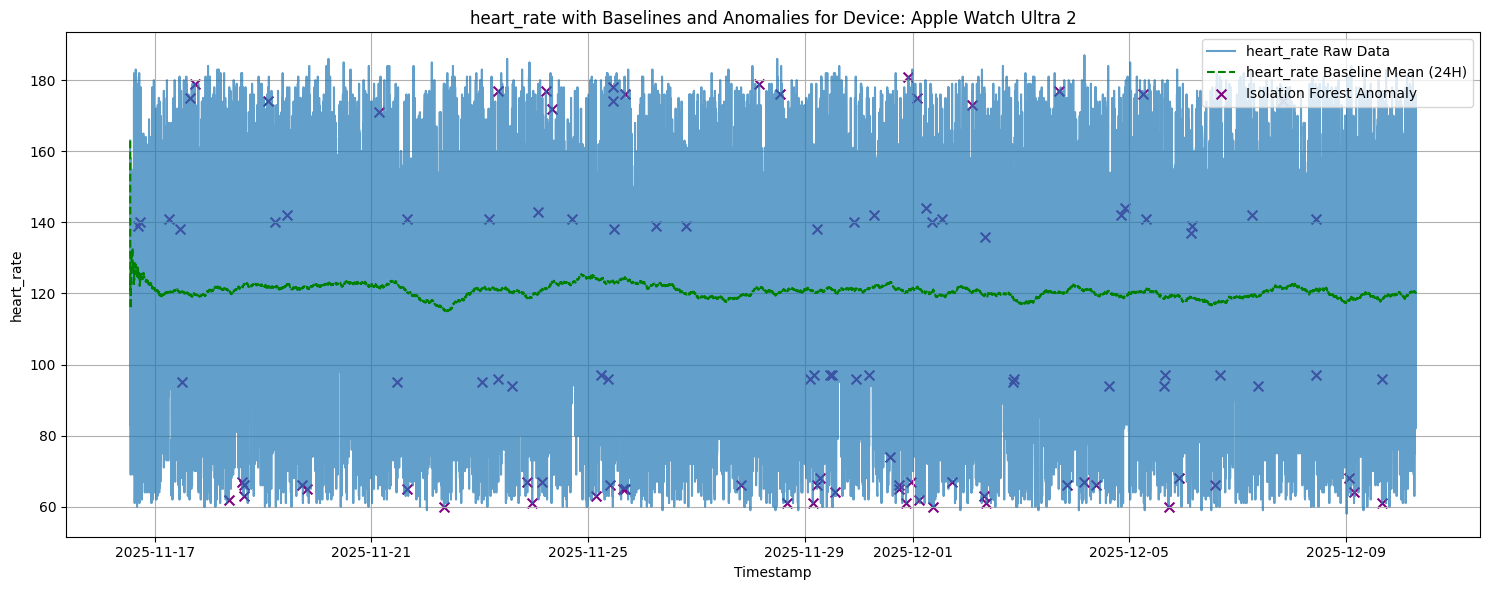

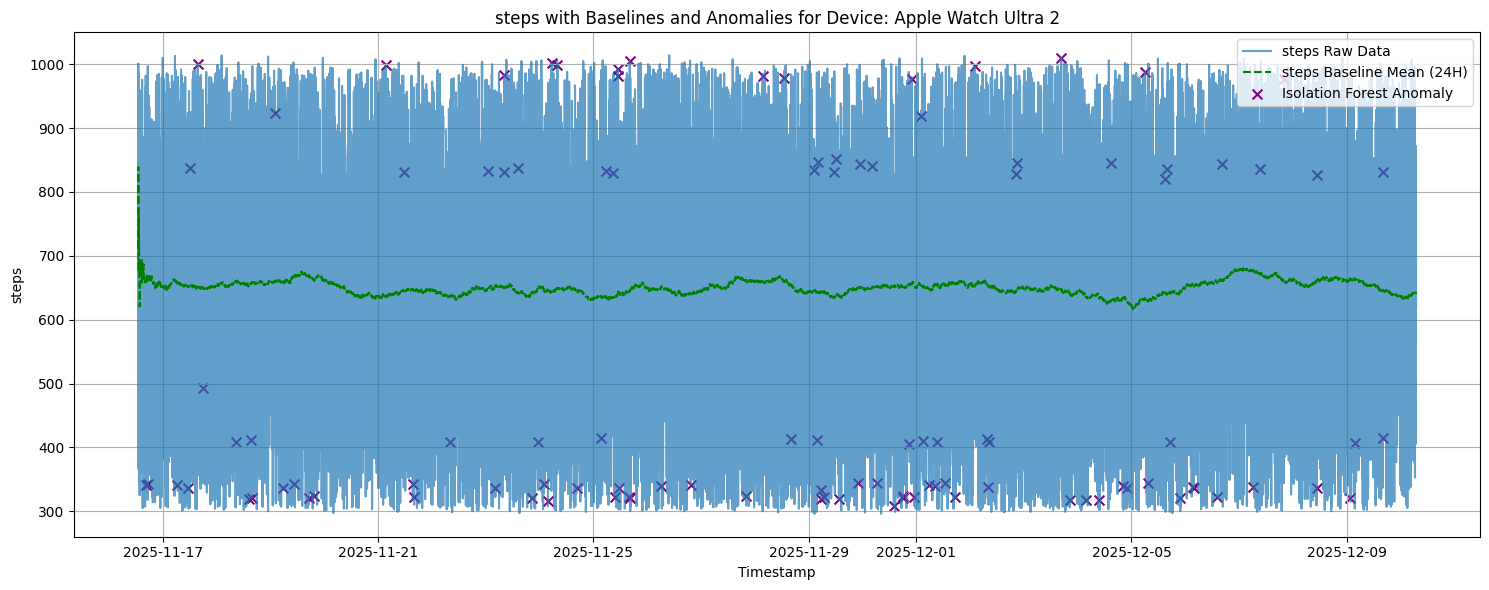

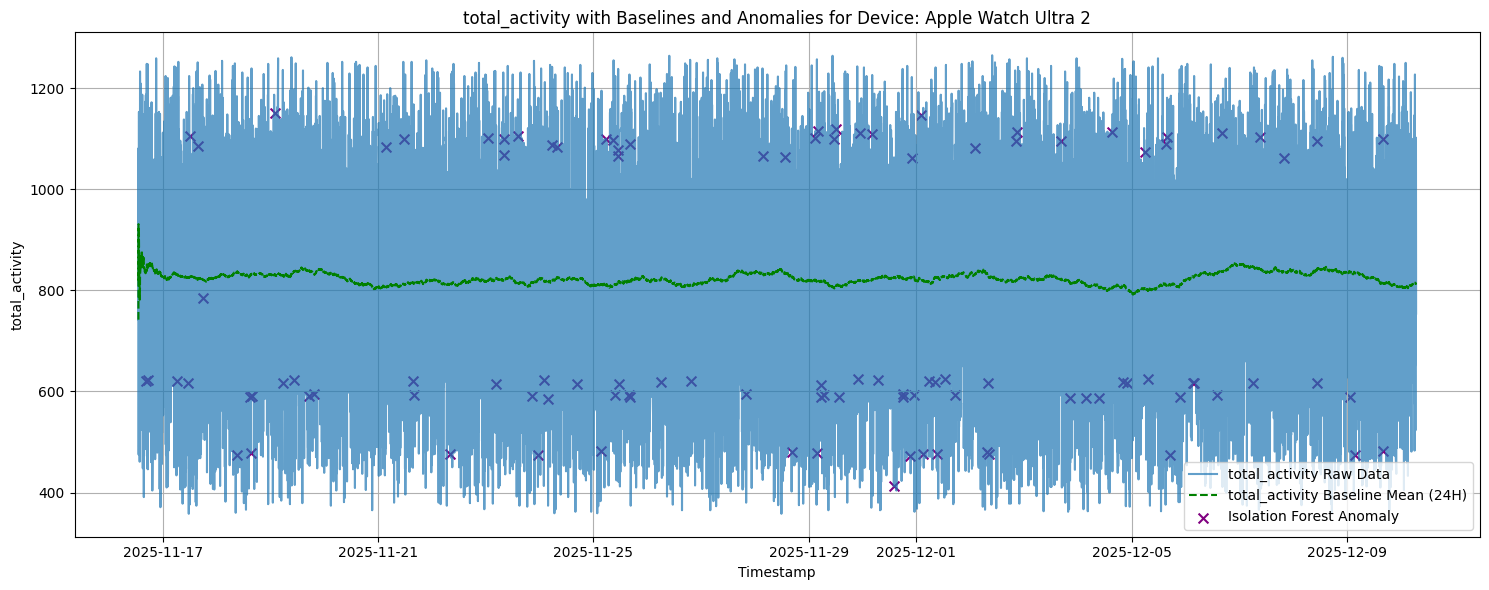


PHIS ML Pipeline: Phase 3 (Machine Learning Pipeline) completed!
The 'health_df' DataFrame now contains baselines and anomaly flags.


In [6]:
# Cell 6: Validation and Visualization

if not health_df.empty:
    # Plotting function to visualize anomalies
    def plot_anomalies(df, feature, device_name=None):
        if device_name:
            df_plot = df[df['device_name'] == device_name].copy()
            title_suffix = f" for Device: {device_name}"
        else:
            df_plot = df.copy()
            title_suffix = ""

        if df_plot.empty:
            print(f"No data to plot for device {device_name}.")
            return

        plt.figure(figsize=(15, 6))
        plt.plot(df_plot.index, df_plot[feature], label=f'{feature} Raw Data', alpha=0.7)
        plt.plot(df_plot.index, df_plot[f'{feature}_baseline_mean'], label=f'{feature} Baseline Mean (24H)', linestyle='--', color='green')

        # Plot Z-score anomalies
        z_anomalies = df_plot[df_plot[f'{feature}_z_anomaly']]
        if not z_anomalies.empty:
            plt.scatter(z_anomalies.index, z_anomalies[feature], color='red', marker='o', s=50, label='Z-score Anomaly')

        # Plot Isolation Forest anomalies (where not already marked by Z-score to avoid clutter)
        # This will show IF anomalies that are NOT Z-score anomalies for the specific feature
        if_anomalies = df_plot[df_plot['isolation_forest_anomaly'] & ~df_plot[f'{feature}_z_anomaly']]
        if not if_anomalies.empty:
            plt.scatter(if_anomalies.index, if_anomalies[feature], color='purple', marker='x', s=50, label='Isolation Forest Anomaly')


        plt.title(f'{feature} with Baselines and Anomalies{title_suffix}')
        plt.xlabel('Timestamp')
        plt.ylabel(feature)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Get a list of unique device names to iterate or pick one
    unique_devices = health_df['device_name'].unique()
    if len(unique_devices) > 0:
        print(f"\nVisualizing anomalies for a sample device: {unique_devices[0]}")
        # Example visualizations for a specific device and feature
        plot_anomalies(health_df, 'heart_rate', unique_devices[0])
        plot_anomalies(health_df, 'steps', unique_devices[0])
        plot_anomalies(health_df, 'total_activity', unique_devices[0])
    else:
        print("No unique devices found to plot.")

    print("\nPHIS ML Pipeline: Phase 3 (Machine Learning Pipeline) completed!")
    print("The 'health_df' DataFrame now contains baselines and anomaly flags.")
    # You would typically save this processed DataFrame or push anomalies back to the DB here for Phase 4.
else:
    print("No data to visualize anomalies.")

In [7]:
# Cell 7: Insight Generation Logic and Storage

if not health_df.empty:
    print("\n--- Generating Insights ---")

    insights_to_save = []

    # Define some heuristic rules for insights
    for index, row in health_df.iterrows():
        device_name = row['device_name']
        timestamp = index # The DataFrame index is the timestamp

        # Rule 1: High Heart Rate Anomaly
        if row['heart_rate_z_anomaly'] and row['heart_rate'] > row['heart_rate_baseline_mean']:
            insight = {
                'timestamp': timestamp,
                'device_name': device_name,
                'metric_involved': 'heart_rate',
                'anomaly_type': 'high_hr',
                'insight_text': f"Your heart rate ({row['heart_rate']} bpm) is significantly higher than your typical average. Consider taking a break and resting.",
                'severity': 'moderate'
            }
            insights_to_save.append(insight)

        # Rule 2: Low Steps Anomaly + High Heart Rate (suggests passive activity or stress)
        if row['steps_z_anomaly'] and row['steps'] < row['steps_baseline_mean'] and \
           row['heart_rate_z_anomaly'] and row['heart_rate'] > row['heart_rate_baseline_mean']:
            insight = {
                'timestamp': timestamp,
                'device_name': device_name,
                'metric_involved': 'steps, heart_rate',
                'anomaly_type': 'low_steps_high_hr',
                'insight_text': f"Your step count ({row['steps']}) is unusually low while your heart rate ({row['heart_rate']} bpm) is elevated. You might be experiencing stress or prolonged sedentary periods. Try to move around.",
                'severity': 'moderate'
            }
            insights_to_save.append(insight)

        # Rule 3: Low Sleep Duration Anomaly
        if row['sleep_duration_z_anomaly'] and row['sleep_duration'] < row['sleep_duration_baseline_mean']:
            insight = {
                'timestamp': timestamp,
                'device_name': device_name,
                'metric_involved': 'sleep_duration',
                'anomaly_type': 'low_sleep',
                'insight_text': f"Your sleep duration ({row['sleep_duration']:.1f} hours) is shorter than usual. Aim for more restful sleep.",
                'severity': 'low'
            }
            insights_to_save.append(insight)

        # Rule 4: High Body Temperature Anomaly
        if row['body_temperature_z_anomaly'] and row['body_temperature'] > row['body_temperature_baseline_mean']:
            insight = {
                'timestamp': timestamp,
                'device_name': device_name,
                'metric_involved': 'body_temperature',
                'anomaly_type': 'high_temp',
                'insight_text': f"Your body temperature ({row['body_temperature']:.1f}°C) is elevated. This could indicate a fever or strenuous activity. Monitor yourself.",
                'severity': 'moderate'
            }
            insights_to_save.append(insight)
            
        # Rule 5: Overall Isolation Forest Anomaly (more general, less specific advice)
        if row['isolation_forest_anomaly'] and not row['overall_anomaly']: # Only if not covered by a more specific rule already
             insight = {
                'timestamp': timestamp,
                'device_name': device_name,
                'metric_involved': 'multiple',
                'anomaly_type': 'overall_if',
                'insight_text': "An unusual pattern has been detected in your health metrics. This could indicate a subtle shift in your health trends. Consider reviewing your recent activity.",
                'severity': 'low'
            }
             insights_to_save.append(insight)


    if insights_to_save:
        conn = None
        try:
            conn = get_db_connection()
            cur = conn.cursor()
            
            # Using executemany for efficient insertion
            insert_query = """
            INSERT INTO insights (timestamp, device_name, metric_involved, anomaly_type, insight_text, severity)
            VALUES (%s, %s, %s, %s, %s, %s)
            """
            
            # Prepare data in the correct order for the query
            data_to_insert = [
                (i['timestamp'], i['device_name'], i['metric_involved'], i['anomaly_type'], i['insight_text'], i['severity'])
                for i in insights_to_save
            ]
            
            cur.executemany(insert_query, data_to_insert)
            conn.commit()
            cur.close()
            conn.close()
            print(f"Successfully saved {len(insights_to_save)} insights to the database.")
        except Exception as e:
            print(f"Error saving insights to database: {e}")
            if conn:
                conn.close()
    else:
        print("No insights generated for the current data batch.")

    print("\nPHIS ML Pipeline: Phase 4 (Insight Generation) completed!")

else:
    print("No processed data available to generate insights.")


--- Generating Insights ---
Successfully saved 1285 insights to the database.

PHIS ML Pipeline: Phase 4 (Insight Generation) completed!
